In [12]:
import uproot

In [13]:
file=uproot.open("../output_file/FE_100/SECOND_test.root")

In [2]:
%pip install scipy

  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.2 MB)

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


True Detector Rate: 678 cps
Measured Rate (after dead time): 0 cps
Detector Live Fraction: 0.0%


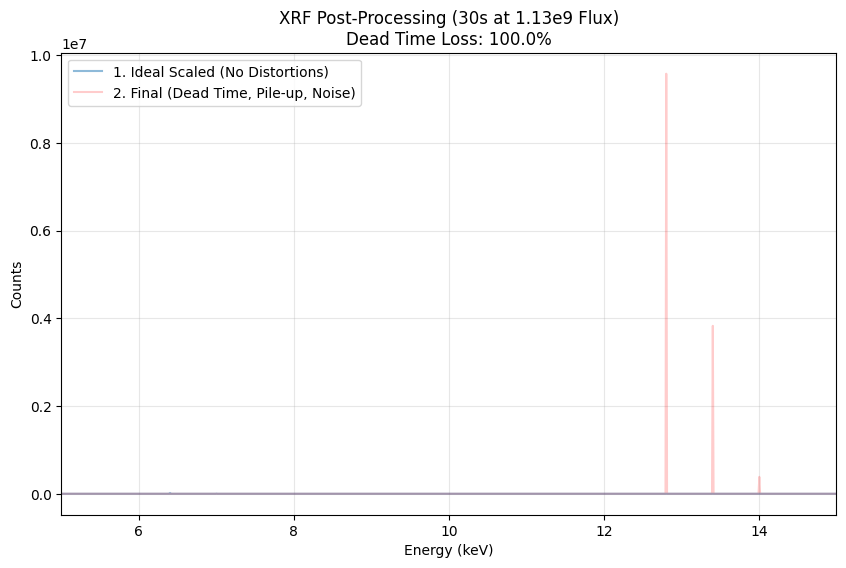

In [10]:
import numpy as np
from scipy.signal import fftconvolve
import matplotlib.pyplot as plt

# ==========================================
# 1. SETUP & SCALING TO REAL WORLD TIME
# ==========================================
real_time_seconds = 30
flux_hitting_sample = 1.13e9 # 1.13 Billion photons/sec
simulated_events = 100000000 # 100 Million Geant4 events

# Calculate the scaling factor
total_real_photons = flux_hitting_sample * real_time_seconds
scaling_factor = total_real_photons / simulated_events

# (Mock Data: Let's pretend Geant4 output is an array of 2000 energy bins up to 20 keV)
# In reality, you load your 'SECOND_test.root' histogram here.
energy_bins = np.linspace(0, 20, 2000)
geant4_spectrum = np.zeros(2000)
geant4_spectrum[640] = 50  # Mock Fe Ka peak at 6.4 keV (50 simulated counts)
geant4_spectrum[700] = 10  # Mock Fe Kb peak at 7.0 keV (10 simulated counts)

# Scale up to the true expected counts for a 30-second run
expected_spectrum = geant4_spectrum * scaling_factor

# ==========================================
# 2. CALCULATE DETECTOR DEAD TIME
# ==========================================
# The detector rate is based on what actually reaches the detector lens
true_detector_counts = np.sum(expected_spectrum)
true_detector_rate = true_detector_counts / real_time_seconds 

pileup_window_s = 1000e-3 # 100 nanoseconds

# Paralyzable Dead Time Equation: Measured = True * exp(-True * window)
measured_detector_rate = true_detector_rate * np.exp(-true_detector_rate * pileup_window_s)
dead_time_survival_fraction = measured_detector_rate / true_detector_rate

print(f"True Detector Rate: {true_detector_rate:,.0f} cps")
print(f"Measured Rate (after dead time): {measured_detector_rate:,.0f} cps")
print(f"Detector Live Fraction: {dead_time_survival_fraction:.1%}")

# Scale down the whole spectrum by the dead time loss
dt_spectrum = expected_spectrum * dead_time_survival_fraction

# ==========================================
# 3. CALCULATE PILE-UP (SUM PEAKS)
# ==========================================
# Probability of two photons arriving within the 100ns window
pileup_probability = true_detector_rate * pileup_window_s

# To mathematically model Pile-up, we Convolve the spectrum with itself!
# If a 6.4 keV and 7.0 keV photon hit simultaneously, convolution mathematically 
# adds them to create a 13.4 keV false peak.
normalized_shape = dt_spectrum / np.sum(dt_spectrum)
sum_shape = fftconvolve(normalized_shape, normalized_shape, mode='full')

# Convolution doubles the array length, so we truncate it back to our 2000 bins
sum_shape = sum_shape[:len(energy_bins)]

# Multiply the convolved shape by the number of piled-up photons
total_pileup_counts = np.sum(expected_spectrum) * pileup_probability
pileup_spectrum = sum_shape * total_pileup_counts

# Add the sum peaks to the main spectrum
spectrum_with_pileup = dt_spectrum + pileup_spectrum

# ==========================================
# 4. APPLY POISSON NOISE
# ==========================================
# Real detectors count whole photons with statistical randomness (square root of N)
spectrum_with_pileup = np.maximum(spectrum_with_pileup, 0)

# Real detectors count whole photons with statistical randomness (square root of N)
final_realistic_spectrum = np.random.poisson(lam=spectrum_with_pileup)
# ==========================================
# PLOT THE TRANSFORMATION
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(energy_bins, expected_spectrum, label="1. Ideal Scaled (No Distortions)", alpha=0.5)

plt.plot(energy_bins, final_realistic_spectrum, label="2. Final (Dead Time, Pile-up, Noise)", color='red',alpha=0.2)
plt.title(f"XRF Post-Processing (30s at 1.13e9 Flux)\nDead Time Loss: {100*(1-dead_time_survival_fraction):.1f}%")
plt.xlabel("Energy (keV)")
plt.ylabel("Counts")
plt.legend()
plt.xlim(5, 15)
plt.grid(True, alpha=0.3)
plt.show()

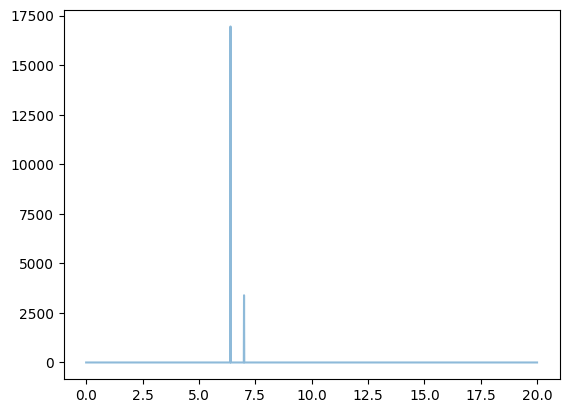

In [14]:
file.keys()

['detectorMetata;1',
 'hits;1',
 'shieldInformation;1',
 'totalEnergyDeposited;1',
 'det_0_spectrum;1',
 'det_1_spectrum;1',
 'det_2_spectrum;1',
 'det_3_spectrum;1',
 'det_4_spectrum;1',
 'det_5_spectrum;1',
 'det_6_spectrum;1',
 'det_7_spectrum;1',
 'det_8_spectrum;1',
 'det_9_spectrum;1',
 'det_10_spectrum;1']

In [15]:
hits=file['hits']

In [16]:
meta=file['detectorMetata']
data = meta.arrays(library="np")
for name, values in data.items():
    print(name, values)

DetectorId [ 0  1  2  3  4  5  6  7  8  9 10]
MaterialComposition ['G4_Fe' 'G4_Fe' 'G4_Fe' 'G4_Fe' 'G4_Fe' 'G4_Fe' 'G4_Fe' 'G4_Fe' 'G4_Fe'
 'G4_Fe' 'G4_Fe']
SampleSizeWidht_mm [5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.]
SampleSizeHeight_mm [5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.]
SampleSizeThickness_mm [0.005 0.005 0.005 0.005 0.005 0.005 0.005 0.005 0.005 0.005 0.005]
IncidentAngle_deg [44.99999064 44.99999064 44.99999064 44.99999064 44.99999064 44.99999064
 44.99999064 44.99999064 44.99999064 44.99999064 44.99999064]
SourceDistance_mm [10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.]
DetectorDistance_mm [5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.]
TakeoffAngle_deg [88.00309484 58.86079549 45.00000936 58.86079549  1.99692388 50.14430455
 45.00000936 50.14430455 70.00002008 45.00000936 19.99999865]
DetectorLocationX_mm [6.83282863 3.53553448 3.53553448 3.53553448 0.23824034 3.53553448
 3.53553448 3.53553448 5.18418156 3.53553448 1.88688741]
DetectorLocationY_mm [ 0.         -4.66307886  0.          4.66307886  0. 

In [39]:
meta=file['detectorMetata']
df=meta.arrays(library='pd')

In [40]:
df.columns

Index(['DetectorId', 'MaterialComposition', 'SampleSizeWidht_mm',
       'SampleSizeHeight_mm', 'SampleSizeThickness_mm', 'IncidentAngle_deg',
       'SourceDistance_mm', 'DetectorDistance_mm', 'TakeoffAngle_deg',
       'DetectorLocationX_mm', 'DetectorLocationY_mm', 'DetectorLocationZ_mm',
       'DetectorWidth_mm', 'DetectorThickness_mm', 'DetectorHeight_mm',
       'WorldMaterial', 'DetectorType', 'IsVirtualDetector',
       'VirtualDetectorCopyNumbers'],
      dtype='str')

In [42]:
virtual_detector=df[df['IsVirtualDetector']==1]

In [43]:
virtual_detector

,DetectorId,MaterialComposition,SampleSizeWidht_mm,SampleSizeHeight_mm,SampleSizeThickness_mm,IncidentAngle_deg,SourceDistance_mm,DetectorDistance_mm,TakeoffAngle_deg,DetectorLocationX_mm,DetectorLocationY_mm,DetectorLocationZ_mm,DetectorWidth_mm,DetectorThickness_mm,DetectorHeight_mm,WorldMaterial,DetectorType,IsVirtualDetector,VirtualDetectorCopyNumbers
5,5,G4_Fe,5.0,5.0,0.005,44.999991,10.0,5.0,50.144305,3.535534,-2.331539,3.535533,9.326158,0.5,4.663079,G4_AIR,,1,"[1, 2]"
6,6,G4_Fe,5.0,5.0,0.005,44.999991,10.0,5.0,45.000009,3.535534,0.000000,3.535533,13.989237,0.5,4.663079,G4_AIR,,1,"[1, 2, 3]"
7,7,G4_Fe,5.0,5.0,0.005,44.999991,10.0,5.0,50.144305,3.535534,2.331539,3.535533,9.326158,0.5,4.663079,G4_AIR,,1,"[2, 3]"
8,8,G4_Fe,5.0,5.0,0.005,44.999991,10.0,5.0,70.000020,5.184182,0.000000,1.886886,4.663079,0.5,9.326158,G4_AIR,,1,"[0, 2]"
9,9,G4_Fe,5.0,5.0,0.005,44.999991,10.0,5.0,45.000009,3.535534,0.000000,3.535533,4.663079,0.5,13.989237,G4_AIR,,1,"[0, 2, 4]"
10,10,G4_Fe,5.0,5.0,0.005,44.999991,10.0,5.0,19.999999,1.886887,0.000000,5.184181,4.663079,0.5,9.326158,G4_AIR,,1,"[2, 4]"


In [50]:
from ast import literal_eval
import numpy as np

In [51]:
for i in virtual_detector['VirtualDetectorCopyNumbers']:
    print(np.array(i))

[1 2]
[1 2 3]
[2 3]
[0 2]
[0 2 4]
[2 4]


In [17]:
meta['VirtualDetectorCopyNumbers'].arrays(library='np')

{'VirtualDetectorCopyNumbers': array([array([], dtype=int32), array([], dtype=int32),
        array([], dtype=int32), array([], dtype=int32),
        array([], dtype=int32), array([1, 2], dtype=int32),
        array([1, 2, 3], dtype=int32), array([2, 3], dtype=int32),
        array([0, 2], dtype=int32), array([0, 2, 4], dtype=int32),
        array([2, 4], dtype=int32)], dtype=object)}

In [18]:
meta['DetectorId'].arrays(library='np')

{'DetectorId': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10], dtype=int32)}

In [19]:
meta.keys()

['DetectorId',
 'MaterialComposition',
 'SampleSizeWidht_mm',
 'SampleSizeHeight_mm',
 'SampleSizeThickness_mm',
 'IncidentAngle_deg',
 'SourceDistance_mm',
 'DetectorDistance_mm',
 'TakeoffAngle_deg',
 'DetectorLocationX_mm',
 'DetectorLocationY_mm',
 'DetectorLocationZ_mm',
 'DetectorWidth_mm',
 'DetectorThickness_mm',
 'DetectorHeight_mm',
 'WorldMaterial',
 'DetectorType',
 'IsVirtualDetector',
 'VirtualDetectorCopyNumbers']

In [52]:
hist=file['hits;1']

In [53]:
hits.arrays(library='pd')

,detID,trackID,energy_keV,time_ns
0,2,0,6.34985,0.263983
1,4,0,6.34985,0.876895
2,4,0,6.34985,1.660815
3,4,0,7.01536,2.582240
4,0,0,6.34985,3.343136
...,...,...,...,...
1567,4,0,6.34985,167.437950
1568,2,0,6.36271,167.846028
1569,4,0,6.34985,170.575449
1570,3,0,6.36271,170.599468


In [21]:
hist['energy_keV'].array(library='np')

array([6.34985, 6.34985, 6.34985, ..., 6.34985, 6.36271, 7.01695],
      shape=(1572,))

In [22]:
info=hits.arrays(library="np")

In [23]:
info['detID']

array([2, 4, 4, ..., 4, 3, 2], shape=(1572,), dtype=int32)

In [24]:
import pandas as pd 
df=pd.DataFrame(info)

In [25]:
df.columns

Index(['detID', 'trackID', 'energy_keV', 'time_ns'], dtype='str')

In [26]:
import seaborn as sns

In [27]:
df['detID'].unique()

array([2, 4, 0, 1, 3], dtype=int32)

In [28]:
df.time_ns.sort_values(ascending=True)

783       0.065768
0         0.263983
784       0.367313
451       0.399309
1260      0.421930
           ...    
1570    170.599468
1571    170.613108
782     170.905443
1416    171.161011
1417    171.305167
Name: time_ns, Length: 1572, dtype: float64

<Axes: xlabel='energy_keV', ylabel='Count'>

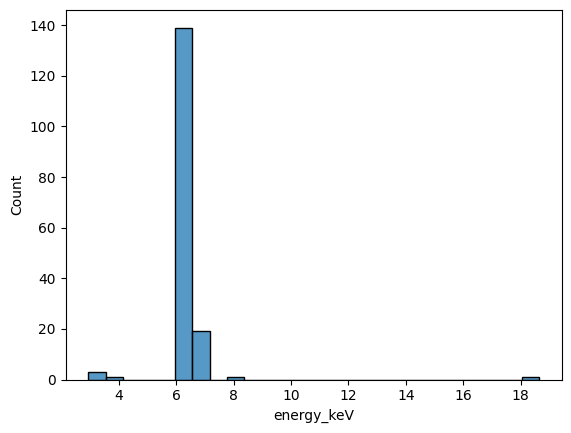

In [29]:
sns.histplot(df[df['detID']==0]["energy_keV"])